# Disciplina: Python no ensino de Matemática


## Aula ??: Visualização de Funções de Variável Complexa.

## Sumário

- [1.Introdução](#1.-Introdução)
- [2. Paisagem Analítica](#2.-Paisagem-Analítica)
- [3. Representações no plano através de cores](#3.-Representações-no-plano-através-de-cores)
    - [3.1.1 Gráficos de fase simples](#3.1.1-Gráficos-de-fase-simples)
    - [3.1.2 Gráficos de fase aprimorado](#3.1.2-Gráficos-de-fase-aprimorado)
    - [3.2 Coloração de domínio](#3.2-Coloração-de-domínio)
- [4. Exemplos](#4.-Exemplos)
- [5. Conclusão](#5.-Conclusão)



## 1. Introdução

Normalmente associamos a visualização de uma função $f: \mathcal{D} \subset \mathbb{R} \rightarrow \mathbb{R}$ com a representação de seu gráfico. Isto é algo bastante claro para todos pois o fazemos desde o Ensino Fundamental.

In [40]:
# Importar PyPlot e NumPy
import matplotlib.pyplot as plt
import numpy as np
# Fonte a ser usada nas figuras geradas pela Matplotlib.
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

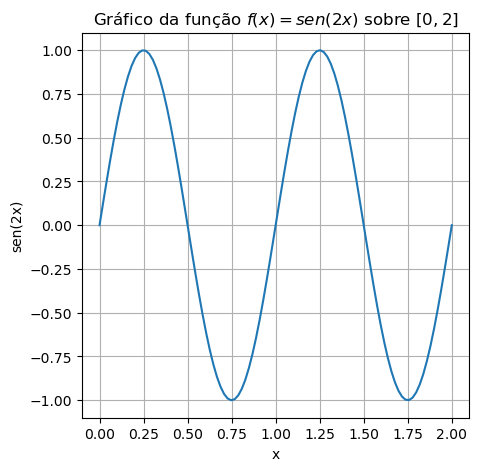

In [41]:
# Valores que serão plotados
x = np.linspace(0, 2, 100)
f = np.sin(2 * np.pi * x)

# Parâmetros da figura
figsize = (5, 5)
colunas = 1
linhas = 1

fig, ax = plt.subplots(linhas, colunas, figsize=figsize)
ax.plot(x, f)

ax.set(xlabel='x', ylabel='sen(2x)',
       title=f'Gráfico da função $f(x) = sen(2x)$ sobre $[0,2]$')
ax.grid()

plt.show()

Perceba que o gráfico da função acima é um conjunto de pontos do plano cartesiano: $$\{(x,\text{sen}(x)): x \in [0,2]\}.$$

Queremos considerar agora uma função definida num conjunto de números complexos e que tem valores complexos. Uma função $f: \mathcal{D} \subset \mathbb{C} \rightarrow \mathbb{C}$ é chamada de função de variável complexa. A princípio, seu gráfico é um subconjunto de $\mathbb{C}^2$, que não sabemos representar graficamente.

No entanto, se lembrarmos da identificação de $\mathbb{C}$ com $\mathbb{R}^2$, ficará claro que visualizar tais funções é difícil basicamente porque precisaríamos de um gráfico com $4$ dimensões reais. 

De fato, se escrevermos $u(x,y) = Re f(x+iy)$ e $v(x,y) = Im f(x+iy)$, com um pouco de abuso de linguagem, tal gráfico seria o conjunto

$$\{(x,y,u(x,y),v(x,y)): (x,y) \in \mathcal{D}\}.$$

Como estamos acostumados a visualizar objetos de 3 dimensões no máximo, não representaremos o gráfico de $f$. Precisaremos elaborar outras maneiras de visualizar a função $f$.

## 2. Paisagem Analítica

Segundo diversas fontes como ([Wegert, 2012](#ref-wegert)) e ([Campuzano, 2026](#ref-campuzano)) uma das primeiras ilustrações de uma função de variável complexa apareceu no livro *Funktionentafeln mit Formeln und Kurven* de Jahnke e Emde em 1909 e representa a função Gama.

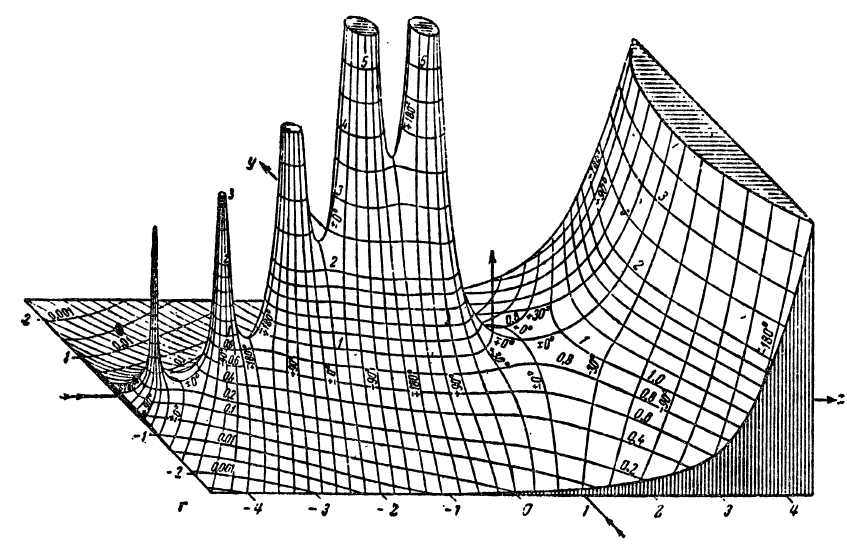

A figura é fruto de um trabalho admirável. Ela foi desenhada à mão pois na época não tinha computadores que pudessem ajudar nessa tarefa. Em cada ponto $(x,y)$ está representado o módulo de $\Gamma(x+iy)$. Esse tipo de representação é chamada de **paisagem analítica**.

Na imagem também aparecem as curvas de nível do argumento e do módulo desses números. Uma versão "contemporânea" desse gráfico é apresentada a seguir. Nela, a informação sobre o argumento é representada através de cores.

Começamos definindo algumas configurações para o gráfico.

In [12]:
#Importar módulos necessários
from matplotlib import cm

# Módulo com funções especiais
import scipy.special

Calculando a função Gamma... Isso pode levar alguns segundos.


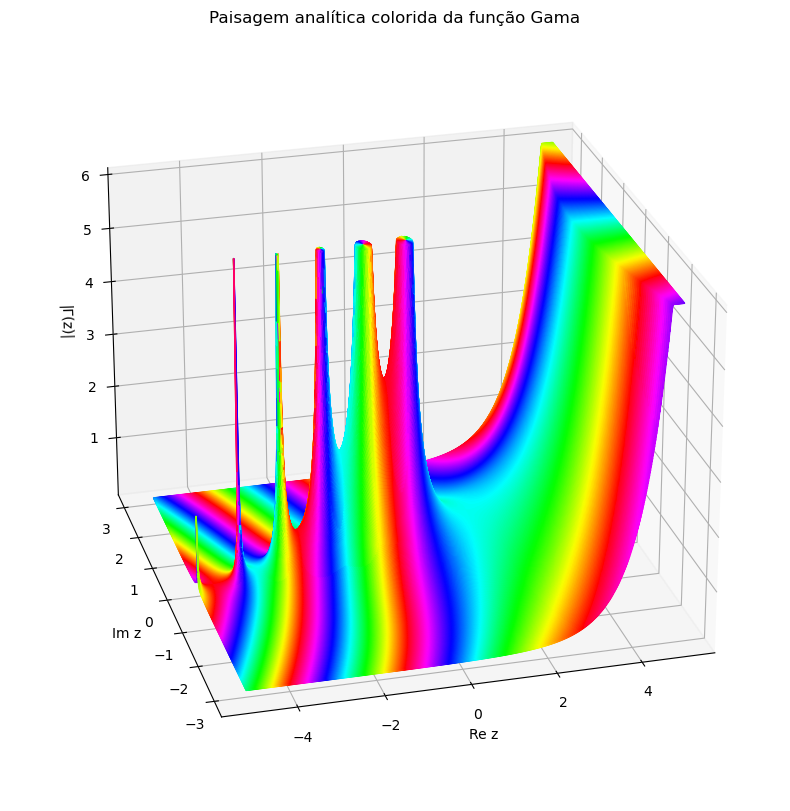

In [47]:
#Comandos para o mesmo gráfico da Gama que aparece acima, só que colocando as cores do círculo 
#de cores no lugar das curvas de nível do argumento.

# Criar a malha de pontos no plano complexo
# Ajuste o intervalo para focar na região mais interessante da Gamma
# (próximo a -5 a 5 no eixo real e -3 a 3 no imaginário)
x = np.linspace(-5, 5, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y  # Números complexos

# Calcular valores da função Gamma
print("Calculando valores da função Gamma... Isso pode levar alguns segundos.")
Gamma_vals = scipy.special.gamma(Z)

# Calcular o módulo e a fase
mod = np.abs(Gamma_vals)
phase = np.angle(Gamma_vals)  # Fase em radianos no intervalo [-pi, pi]

# Normalizar a fase para o intervalo [0, 1] para mapear para o colormap HSV
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Para evitar problemas com polos (onde a função explode), limitamos o módulo
mod_limited = np.clip(mod, 0, 6)  # Ajuste o limite conforme necessário

# Criar a figura 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plotar a superfície com a cor baseada na fase
# Usamos o colormap 'hsv' que é um círculo de cores
#surf = ax.plot_surface(X, Y, mod_limited, 
#                        facecolors=cm.hsv(phase_normalized), 
#                        rstride=2, cstride=2, antialiased=True, shade=False)
surf = ax.plot_surface(X, Y, mod_limited, 
                        facecolors=cm.hsv(phase_normalized), 
                        rcount = 500, ccount = 500, antialiased=True, shade=False)
# Ajustar os ângulos de visão para uma boa perspectiva (similar à da figura)
ax.view_init(elev=25, azim = -105)

# Rótulos e título
ax.set_xlabel('Re z')
ax.set_ylabel('Im z')
ax.set_zlabel('|Γ(z)|')
ax.set_title('Paisagem analítica colorida da função Gama', fontsize=12)

plt.show()

Perceba que nesse gráfico perdemos os detalhes que estão por trás das partes mais elevadas. Uma maneira de visualizar o gráfico todo seria projetar ele no plano. 

Há várias maneiras de fazer isso. Discutiremos algumas a seguir.

## 3. Representações no plano através de cores

Este tipo de representação consiste, basicamente, em colorir o domínio da função $f$ usando cores determinadas pelos valores do contradomínio. Por uma questão estritamente didática, chamaremos aqui o plano complexo contendo o domínio, de *plano $z$* e o que contém o contradomínio será chamado de *plano $w$*.

Todos os métodos que vamos apresentar a seguir:

1. Atribuem uma cor a cada ponto do plano $w$.

2. Cada ponto do plano $z$ é então colorido usando a cor de sua imagem por $f$.

Os três tipos de métodos que veremos a seguir se diferenciam apenas na forma em que o *plano $w$* é colorido.

## 3.1 Gráficos de fase

Nos gráficos de fase, cada ponto do plano $w$ é colorido segundo o valor de sua fase $e^{i arg w}$. Uma escolha bastante comum faz corresponder, de forma biunívoca, a cada fase uma cor do círculo de cores, com exceção de $w = 0$, que não tem fase definida e vai ser colorido de preto. 

Nas referências que utilizamos, o mapa de cores associa $1$ à cor vermelha e $-1$ à cor ciano. Por isso, precisaremos rotacionar o mapa *hsv*.

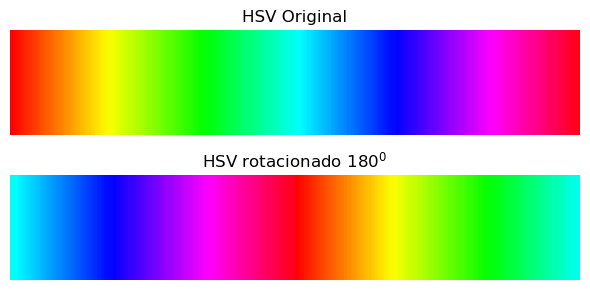

In [18]:
#Rotação do mapa de cores HSV (vermelho -> ângulo zero)
from matplotlib.colors import ListedColormap

def rotate_hsv_cmap(shift_fraction=0.25):
    """
    Creates a rotated version of the HSV colormap.
    
    Parameters:
        shift_fraction (float): Fraction to rotate by (0.0 to 1.0).
                                0.25 shifts the start color by 90 degrees.
    """
    # 1. Fetch the standard HSV colormap colors as an array (usually 256 samples)
    hsv_base = plt.colormaps['hsv']
    color_array = hsv_base(np.linspace(0, 1, 256))
    
    # 2. Calculate how many indices to shift based on the fraction
    shift_indices = int(shift_fraction * len(color_array))
    
    # 3. Cyclically shift the rows of the color array
    rotated_colors = np.roll(color_array, shift=shift_indices, axis=0)
    
    # 4. Create and return the new custom ListedColormap
    return ListedColormap(rotated_colors, name=f'rotated_hsv_{shift_fraction}')

# Generate a rotated colormap shifted by 180 degrees
rotated_hsv = rotate_hsv_cmap(shift_fraction = 0.5)

# Generate sample data to plot
data = np.linspace(0, 1, 256).reshape(1, -1)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 3))
ax1.imshow(data, aspect='auto', cmap='hsv')
ax1.set_title('HSV Original')
ax1.axis('off')

ax2.imshow(data, aspect='auto', cmap=rotated_hsv)
ax2.set_title(r'HSV rotacionado $180^0$')
ax2.axis('off')

plt.tight_layout()
plt.show()

A seguir mostramos, na figura à esquerda, o círculo de cores que usaremos e à direita, como fica colorido o plano $w$. $w = 0$ não foi representado. 

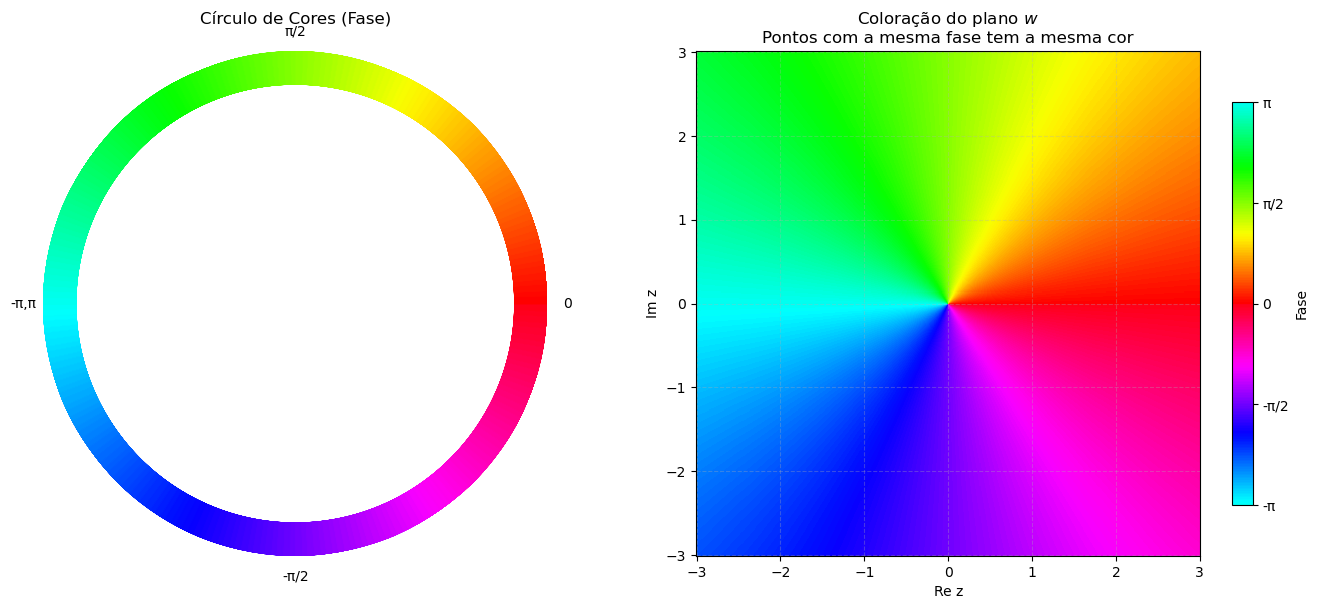

In [65]:
#Gráfico com duas imagens, uma ao lado da outra. à esquerda, o círculo de cores e 
#à direita, um quadrado ([-3,3]x[-3,3]), representando o plano w. 
#no qual cada ponto deverá estar colorido segundo sua fase no círculo de cores 

# --- 1. Círculo de cores (gráfico polar) ---
def plot_color_wheel_polar(ax):
    """Plota a roda de cores usando coordenadas polares."""
    
    # Criar a grade polar
    r = np.linspace(0.87, 1, 700)        # Raio (saturação)
    theta = np.linspace(-np.pi, np.pi, 920)  # Ângulo (matiz/fase)
    R, Theta = np.meshgrid(r, theta)
    
    # Plotar usando pcolormesh em coordenadas polares
    ax.grid(False)
    mesh = ax.pcolormesh(Theta, R, Theta, cmap=rotated_hsv, shading='gouraud')
    
    # Ajustes estéticos
    ax.set_yticklabels([])      # Esconder rótulos do raio
    ax.set_xticklabels([])      # Esconder rótulos dos ângulos
    ax.spines['polar'].set_visible(False)  # Esconder borda externa
    ax.grid(False)              # Esconder grades
    
    # Adicionar marcações dos ângulos principais (opcional)
    angulos = [-np.pi/2, 0, np.pi/2, np.pi]
    labels = ['-π/2', '0', 'π/2', '-π,π']
    
    for ang, label in zip(angulos, labels):
        ax.text(ang, 1.08, label, ha='center', va='center', fontsize=10)
    
    return mesh

# --- 2. Phase Plot (gráfico retangular) ---
def plot_colored_wplane(ax, x_range=(-3, 3), y_range=(-3, 3)):
    """Plota o gráfico de fase da função identidade f(z)=z."""
    
    x = np.linspace(x_range[0], x_range[1], 500)
    y = np.linspace(y_range[0], y_range[1], 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # Calcular a fase
    phase = np.angle(Z)  # em [-π, π]
    phase_normalized = (phase + np.pi) / (2 * np.pi)  # normalizar para [0, 1]

    # Plotar com o colormap hsv rotacionado
    ax.grid(False)
    im = ax.pcolormesh(X, Y, phase_normalized, cmap=rotated_hsv, shading='auto')
    
    # Ajustes
    ax.set_xlabel('Re z', fontsize=10)
    ax.set_ylabel('Im z', fontsize=10)
    ax.set_title('Coloração do plano $w$\nPontos com a mesma fase tem a mesma cor', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Barra de cores
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Fase', fontsize=10)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
    cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    
    return im

# --- 3. Criar a figura com dois subplots lado a lado ---
# IMPORTANTE: cada subplot pode ter sua própria projeção!
fig = plt.figure(figsize=(14, 6))

# Eixo 1: Polar (círculo de cores)
ax1 = fig.add_subplot(1, 2, 1, projection='polar')
plot_color_wheel_polar(ax1)
ax1.set_title('Círculo de Cores (Fase)', fontsize=12, pad=20)

# Eixo 2: Retangular (phase plot)
ax2 = fig.add_subplot(1, 2, 2)
plot_colored_wplane(ax2)

plt.tight_layout()
plt.show()

## 3.1.1 Gráficos de fase simples

Este tipo de gráfico é construído usando como referência a coloração do plano $w$ que mostramos acima, com as observações adicionais:

+ zeros serão coloridos de preto;
+ polos serão coloridos de branco.

Na função a seguir implementamos esse procedimento. Nela, estamos utilizando a variável

+ `epsilon_0` como limiar para considerar um ponto como zero;

+ `1/epsilon_p` como limiar para considerar um ponto como polo.

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def plot_plain_phase_portrait(ax, func, x_range=(-3, 3), y_range=(-3, 3), 
                                    epsilon_0=1e-2, epsilon_p=1e-2, cmap=None):
    """
    Plota o gráfico de fase de uma função complexa, com os zeros em preto e polos em branco.
    
    Parâmetros:
    - ax: eixo do matplotlib
    - func: função f(z) que retorna um array complexo
    - x_range, y_range: intervalo do plano complexo
    - epsilon_0: limiar para considerar um ponto como zero
    - epsilon_p: limiar para considerar um ponto como polo    
    - cmap: colormap a ser usado (opcional)
    """
    
    # Criar a malha
    x = np.linspace(x_range[0], x_range[1], 500)
    y = np.linspace(y_range[0], y_range[1], 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # Calcular a função
    f_vals = func(Z)
    
    # Calcular a fase
    phase = np.angle(f_vals)  # em [-π, π]
    phase_normalized = (phase + np.pi) / (2 * np.pi)  # normalizar para [0, 1]
    
    # Calcular o módulo
    modulus = np.abs(f_vals)
    
    # Criar uma máscara para os zeros (onde |f(z)| < epsilon_0)
    zero_mask = modulus < epsilon_0
    
    # Criar uma máscara para os polos (onde |f(z)| > 1/epsilon_p)
    pole_mask = modulus > 1/epsilon_p

    # Criar a imagem RGB
    if cmap is None:
        # Usar o colormap padrão (rotated_hsv)
         cmap = rotated_hsv  
    
    # Obter as cores da fase
    colors = cmap(phase_normalized)  # shape: (ny, nx, 4) (RGBA)
    
    # Substituir os zeros por preto (R=0, G=0, B=0, A=1)
    # A máscara precisa ser aplicada em todas as camadas de cor
    colors[zero_mask] = [0, 0, 0, 1]  # Preto opaco

    # Substituir os polos por branco (R=1, G=1, B=1, A=1)
    # A máscara precisa ser aplicada em todas as camadas de cor
    colors[pole_mask] = [1, 1, 1, 1]  # Branco
    
    # Plotar a imagem RGB diretamente (mais rápido que pcolormesh)
    ax.imshow(colors, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
              origin='lower', aspect='equal')
    
    # Ajustes
    ax.set_xlabel('Re z', fontsize=10)
    ax.set_ylabel('Im z', fontsize=10)
    ax.set_title(r'Phase Plot com zeros em preto', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    return colors

Nas imagens que seguem mostramos os gráficos de fase simples das funções $$f_1(z) = z,  f_2(z) = e^{i\theta}z,  f_3(z) = z^2,  f_4(z) = \frac{1}{z},  f_5(z) = \frac{e^{i\theta}}{z}  \text{ e }   f_6(z) = \frac{1}{z^2}.$$

Perceba 
+ a diferença entre polos e zeros;
+ o efeito da rotação;
+ o efeito da ordem de polos e zeros.

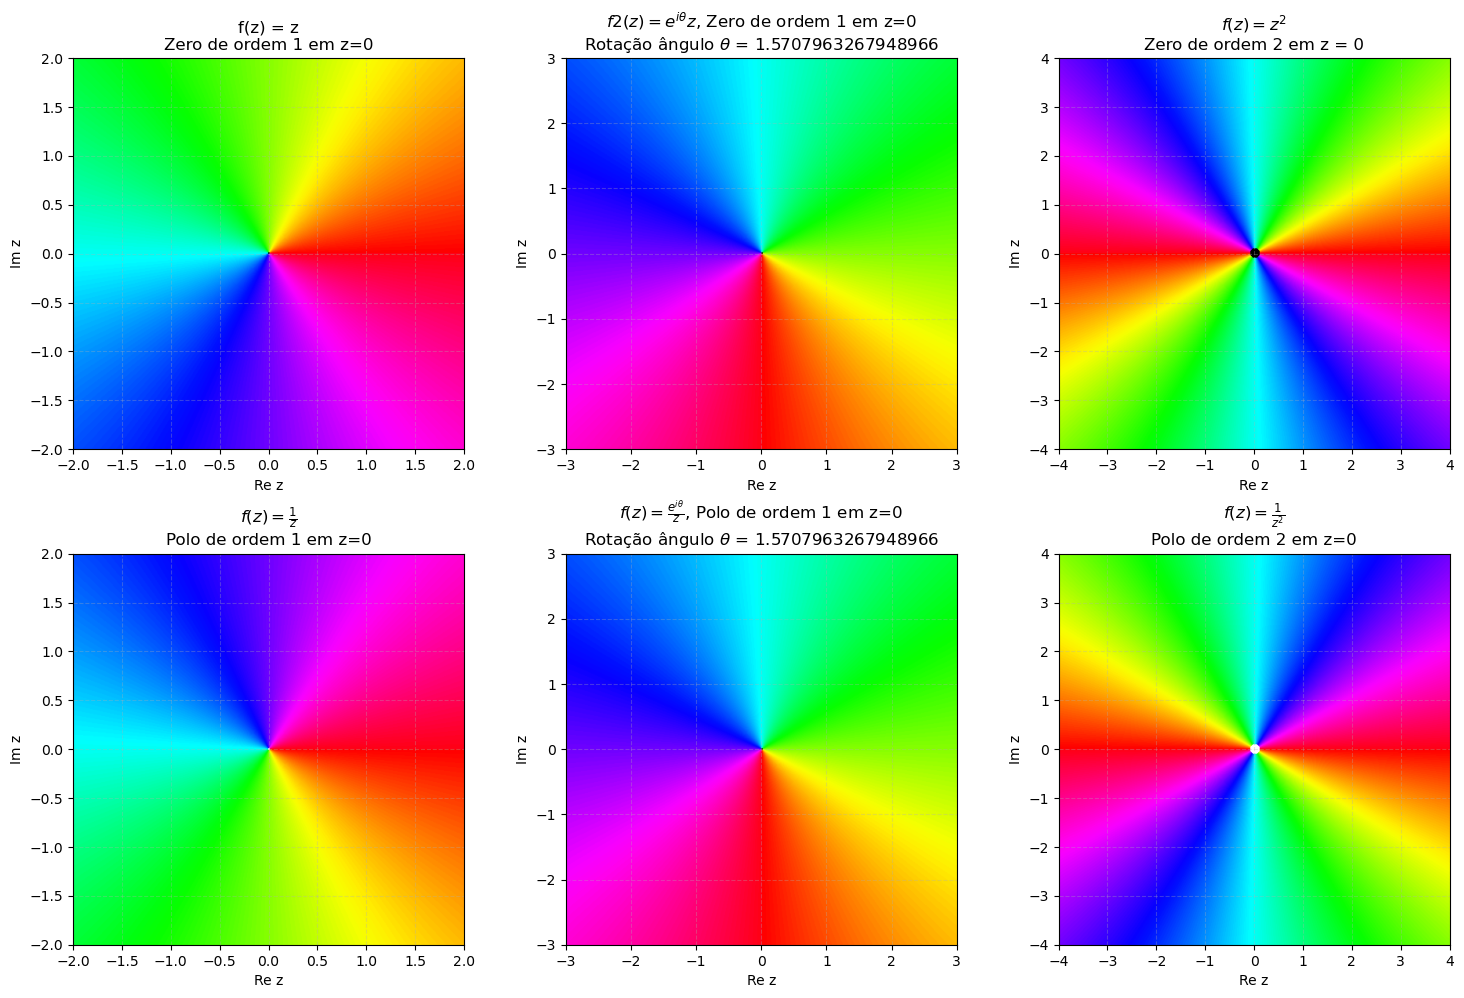

In [88]:
# Gráficos de fase simples de seis funções
theta = np.pi/2
# Definição das funções
def f1(z):
    """f(z) = z (zero de ordem 1 em z=0)"""
    return z

def f2(z):
    """f(z) = e^{i\theta}z (rotaçao ângulo theta e zero de ordem 1 em z=0)"""
    theta = np.pi/2
    return np.exp(1j*theta)*z

def f3(z):
    """f(z) = z^2 (zero de ordem 2 em z = 0)"""
    return z**2

def f4(z):
    """f(z) = 1/z (polo de ordem 1 em z=0)"""
    return 1/z

def f5(z):
    """f(z) = e^{i\theta}/z (rotaçao ângulo theta e polo de ordem 1 em z=0)"""
    return np.exp(1j*theta)*z

def f6(z):
    """f(z) = 1/z^2 (polo de ordem 2 em z = 0)"""
    return 1/z**2

# Criar a figura com 6 exemplos

linhas = 2
colunas = 3
fig, axes = plt.subplots(linhas, colunas, figsize=(15, 10))

# Exemplo 1: f1(z) = z
plot_plain_phase_portrait(axes[0,0], f1, x_range=(-2, 2), y_range=(-2, 2))
axes[0,0].set_title('f(z) = z\nZero de ordem 1 em z=0')

# Exemplo 2: f2(z) = e^{i\theta}z
plot_plain_phase_portrait(axes[0,1], f2, x_range=(-3, 3), y_range=(-3, 3))
axes[0,1].set_title(r'$f2(z) = e^{i\theta}z$, Zero de ordem 1 em z=0' + '\nRotação ângulo '+f'$\\theta$ = {theta}')

# Exemplo 3: f3(z) = z^2
plot_plain_phase_portrait(axes[0,2], f3, x_range=(-4, 4), y_range=(-4, 4))
axes[0,2].set_title(r'$f(z) = z^2$' + '\nZero de ordem 2 em z = 0')

# Exemplo 4: f4(z) = 1/z
plot_plain_phase_portrait(axes[1,0], f4, x_range=(-2, 2), y_range=(-2, 2))
axes[1,0].set_title(r'$f(z) = \frac{1}{z}$'+'\nPolo de ordem 1 em z=0')

# Exemplo 5: f5(z) = e^{i\theta}/z
plot_plain_phase_portrait(axes[1,1], f5, x_range=(-3, 3), y_range=(-3, 3))
axes[1,1].set_title(r'$f(z) = \frac{e^{i\theta}}{z}$, Polo de ordem 1 em z=0' + '\nRotação ângulo '+ f'$\\theta$ = {theta}')

# Exemplo 6: f6(z) = 1/z^2
plot_plain_phase_portrait(axes[1,2], f6, x_range=(-4, 4), y_range=(-4, 4))
axes[1,2].set_title(r'$f(z) = \frac{1}{z^2}$'+'\nPolo de ordem 2 em z=0')

plt.tight_layout()
plt.show()

In [ ]:

# Definição das funções
def f1(z):
    """f(z) = z (zero em z=0)"""
    return 1/z

def f2(z):
    """f(z) = z^2 - 1 (zeros em z=±1)"""
    return z**2 - 1

def f3(z):
    """f(z) = sin(z) (zeros em z = nπ)"""
    return np.sin(z)

# Criar a figura com 3 exemplos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Exemplo 1: f(z) = z
plot_phase_portrait_with_zeros(axes[0], f1, x_range=(-2, 2), y_range=(-2, 2))
axes[0].set_title('f(z) = z\nZero em z=0')

# Exemplo 2: f(z) = z² - 1
plot_phase_portrait_with_zeros(axes[1], f2, x_range=(-3, 3), y_range=(-3, 3))
axes[1].set_title('f(z) = z² - 1\nZeros em z=±1')

# Exemplo 3: f(z) = sin(z)
plot_phase_portrait_with_zeros(axes[2], f3, x_range=(-4, 4), y_range=(-4, 4))
axes[2].set_title('f(z) = sin(z)\nZeros em z = nπ')

plt.tight_layout()
plt.show()

In [ ]:
# Definir a função identidade
def identity(z):
    return z

# Plotar com zeros em preto
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_phase_portrait(ax, identity, x_range=(-3, 3), y_range=(-3, 3))
plt.show()

## 3.1.2 Gráficos de fase aprimorados

## 3.2 Coloração de domínio

## 4. Exemplos

## 5. Conclusão

#### Referências: 

+ https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.pcolormesh.html
+ https://matplotlib.org/stable/gallery/images_contours_and_fields/pcolormesh_levels.html#sphx-glr-gallery-images-contours-and-fields-pcolormesh-levels-py

* <a id="ref-wegert"></a> Elias Wegert.*Visual Complex Functions. An Introduction with Phase Portraits.* Springer. 2012.
* <a id="ref-campuzano"></a> Juan Carlos Ponce Campuzano. *Complex Analysis A Visual and Interactive Introduction.* 2019 - 2026. E-book. Disponível em: https://complex-analysis.com/

In [ ]:
-1/4 % 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

class roll_cmap(LinearSegmentedColormap):
    """
    Colormap com deslocamento cíclico.
    Útil para criar variações do HSV para gráficos de fase.
    """
    def __init__(self, cmap, shift):
        assert 0. < shift < 1.
        self.cmap = cmap
        self.N = cmap.N
        self.monochrome = self.cmap.monochrome
        self._x = np.linspace(0.0, 1.0, 255)
        self._y = np.roll(np.linspace(0.0, 1.0, 255), int(255 * shift))

    def __call__(self, xi, alpha=1.0, **kw):
        yi = np.interp(xi, self._x, self._y)
        return self.cmap(yi, alpha)


def create_wegert_colormap():
    """
    Cria o colormap com a convenção do Wegert usando o rolling do HSV.
    Shift = 0.9167 (ou -0.0833) alinha as cores corretamente.
    """
    # Shift calculado: queremos que o verde (posição 1/3) vá para π/2 (posição 0.25)
    # shift = 0.25 - 1/3 = -1/12 ≈ -0.0833
    # Em [0, 1]: shift = 1 - 1/12 = 11/12 ≈ 0.9167
    shift = 11/12  # ≈ 0.9167
    return roll_cmap(plt.cm.hsv, shift=shift)


def plot_color_wheel_polar(ax, shift=11/12):
    """Roda de cores com a convenção do Wegert."""
    
    r = np.linspace(0.77, 1, 500)
    theta = np.linspace(0, 2*np.pi, 720)
    R, Theta = np.meshgrid(r, theta)
    
    # Usar o colormap com shift
    cmap = roll_cmap(plt.cm.hsv, shift=shift)
    
    mesh = ax.pcolormesh(Theta, R, Theta, cmap=cmap, shading='gouraud')
    
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.spines['polar'].set_visible(False)
    ax.grid(False)
    
    # Marcações dos ângulos principais
    angulos = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
    labels = ['-π', '-π/2', '0', 'π/2', 'π']
    
    for ang, label in zip(angulos, labels):
        ax.text(ang, 1.08, label, ha='center', va='center', fontsize=10)
    
    return mesh


def plot_phase_portrait(ax, x_range=(-3, 3), y_range=(-3, 3), shift=11/12):
    """Phase plot com a convenção do Wegert."""
    
    x = np.linspace(x_range[0], x_range[1], 500)
    y = np.linspace(y_range[0], y_range[1], 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    phase = np.angle(Z)
    phase_normalized = (phase + np.pi) / (2 * np.pi)
    
    # Usar o colormap com shift
    cmap = roll_cmap(plt.cm.hsv, shift=shift)
    
    im = ax.pcolormesh(X, Y, phase_normalized, cmap=cmap, shading='auto')
    
    ax.set_xlabel('Re z', fontsize=10)
    ax.set_ylabel('Im z', fontsize=10)
    ax.set_title('Phase Plot (Wegert Convention)', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Fase', fontsize=10)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
    cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    
    return im


# --- Criar a figura ---
fig = plt.figure(figsize=(14, 6))

# Círculo de cores (polar)
ax1 = fig.add_subplot(1, 2, 1, projection='polar')
plot_color_wheel_polar(ax1)
ax1.set_title('Roda de Cores (Wegert)', fontsize=12, pad=20)

# Phase plot (retangular)
ax2 = fig.add_subplot(1, 2, 2)
plot_phase_portrait(ax2)

plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap

# Get 256 RGBA values from the standard hsv colormap
hsv_vals = plt.cm.hsv(np.linspace(0, 1, 256))

# Shift the array so that red (originally at index 0) moves to the desired position
# Shift by -16/256 roughly corresponds to aligning the hue wheel rotation
hsv_rolled = np.roll(hsv_vals, shift=-int(256 * 0.0), axis=0) 
red_zero_cmap = ListedColormap(hsv_rolled)

In [ ]:
from matplotlib.colors import hsv_to_rgb

# Create a sample complex grid (domain coloring of z = x + i*y)
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Compute angle (hue) and magnitude (brightness)
hue = (np.angle(Z) + np.pi) / (2 * np.pi)  # Map [-pi, pi] to [0, 1]
mag = np.abs(Z)
val = mag / (1 + mag)  # Normalize magnitude to [0, 1] smoothly

# Build HSV and convert to RGB
hsv = np.dstack((hue, np.ones_like(hue), val))
rgb = hsv_to_rgb(hsv)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(rgb, extent=[-2, 2, -2, 2])
plt.axis('off')
plt.show()

In [ ]:
def plot_phase_portrait(ax, cmap, x_range=(-3, 3), y_range=(-3, 3)):
    """Plota o phase plot da função identidade f(z)=z."""
    
    x = np.linspace(x_range[0], x_range[1], 500)
    y = np.linspace(y_range[0], y_range[1], 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # Calcular a fase
    phase = np.angle(Z)  # em [-π, π]
    phase_normalized = (phase + np.pi) / (2 * np.pi)  # normalizar para [0, 1]
    #phase_normalized = (phase / (2 * np.pi)) % 1  # normalizar para [0, 1] 

    # Plotar com o colormap hsv
    ax.grid(False)
    im = ax.pcolormesh(X, Y, phase_normalized, cmap=cmap, shading='auto')
    
    # Ajustes
    ax.set_xlabel('Re z', fontsize=10)
    ax.set_ylabel('Im z', fontsize=10)
    ax.set_title('Phase Plot of f(z) = z', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Barra de cores
    cbar = plt.colorbar(im, ax=ax, cmap=cmap, shrink=0.8)
    cbar.set_label('Fase (argumento)', fontsize=10)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
    cbar.set_ticklabels(['0', 'π/2', 'π', '-π/2', '0'])
    
    return im

# --- 3. Criar a figura com dois subplots lado a lado ---
# IMPORTANTE: cada subplot pode ter sua própria projeção!
fig = plt.figure(figsize=(14, 6))

# Eixo 1: Polar (círculo de cores)
ax1 = fig.add_subplot(1, 2, 1, projection='polar')
plot_color_wheel_polar(ax1)
ax1.set_title('Roda de Cores (Fase)', fontsize=12, pad=20)

# Eixo 2: Retangular (phase plot)
ax2 = fig.add_subplot(1, 2, 2)
plot_phase_portrait(ax2,cmap=rotated_hsv)

plt.tight_layout()
plt.show()

In [ ]:
def rotate_hsv_cmap(shift_fraction=0.25):
    """
    Creates a rotated version of the HSV colormap.
    
    Parameters:
        shift_fraction (float): Fraction to rotate by (0.0 to 1.0).
                                0.25 shifts the start color by 90 degrees.
    """
    # 1. Fetch the standard HSV colormap colors as an array (usually 256 samples)
    hsv_base = plt.colormaps['hsv']
    color_array = hsv_base(np.linspace(0, 1, 256))
    
    # 2. Calculate how many indices to shift based on the fraction
    shift_indices = int(shift_fraction * len(color_array))
    
    # 3. Cyclically shift the rows of the color array
    rotated_colors = np.roll(color_array, shift=shift_indices, axis=0)
    
    # 4. Create and return the new custom ListedColormap
    return ListedColormap(rotated_colors, name=f'rotated_hsv_{shift_fraction}')

# --- Example Usage ---
# Generate a rotated colormap shifted by 120 degrees (approx 0.33)
rotated_hsv = rotate_hsv_cmap(shift_fraction=0.5)

# Generate sample data to plot
data = np.linspace(0, 1, 256).reshape(1, -1)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 3))
ax1.imshow(data, aspect='auto', cmap='hsv')
ax1.set_title('Original HSV')
ax1.axis('off')

ax2.imshow(data, aspect='auto', cmap=rotated_hsv)
ax2.set_title('Rotated HSV (Shifted by 0.33)')
ax2.axis('off')

plt.tight_layout()
plt.show()